Problem: 1

C:\Users\USER

Age Mean: 43.90, SD: 14.60
Age Skewness: 0.0121
Smoking Proportions:
 Smoking
No     0.586
Yes    0.414
Name: proportion, dtype: float64
Income with highest frequency: Low
Pollution (High) Percentage: 70.40%
Overall prevalence of lung disease: 52.80%
Contingency Table (Smoking vs Lung Disease):
 LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155
Chi-square p-value (Smoking): 2.0085e-16
Chi-square p-value (Pollution): 5.9757e-09
Odds Ratio for Smoking: 5.03
Optimization terminated successfully.
         Current function value: 0.552949
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     LungDisease_binary   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:                            5
Date:                Sat, 16 May 2026   Pseudo R-squ.:               

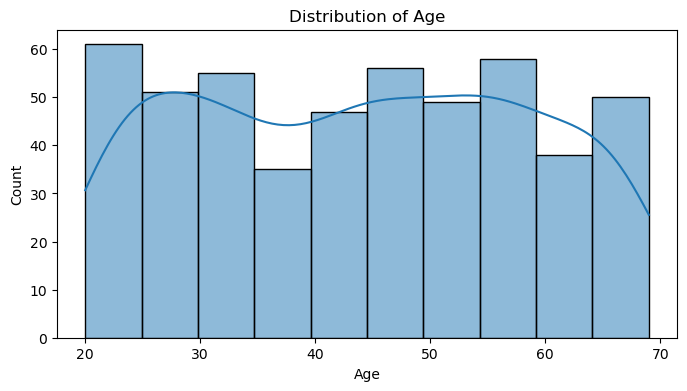

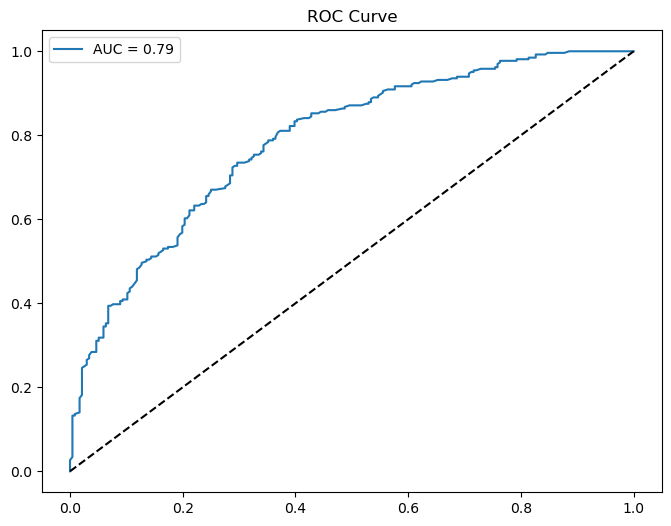

In [1]:

# current working directory
import os
print(os.getcwd())
print() 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score

# 1. Load Data
df = pd.read_csv(r"D:\Assignment-on-CDA-STAT4101\lung_disease.csv")

# Pre-processing: Convert categorical variables to binary/numeric for modeling
df['Smoking_binary'] = df['Smoking'].map({'Yes': 1, 'No': 0})
df['LungDisease_binary'] = df['LungDisease'].map({'Yes': 1, 'No': 0})
df['Pollution_binary'] = df['Pollution'].map({'High': 1, 'Low': 0})

# --- BASIC EDA ---
# i) Age Distribution
print(f"Age Mean: {df['Age'].mean():.2f}, SD: {df['Age'].std():.2f}")
print(f"Age Skewness: {df['Age'].skew():.4f}")
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')
plt.savefig('age_distribution.png')

# ii) Smoking Proportion
print("Smoking Proportions:\n", df['Smoking'].value_counts(normalize=True))

# iii) Income Frequency
print(f"Income with highest frequency: {df['Income'].mode()[0]}")

# iv) Pollution Exposure
print(f"Pollution (High) Percentage: {(df['Pollution'] == 'High').mean()*100:.2f}%")

# v) Lung Disease Prevalence
print(f"Overall prevalence of lung disease: {df['LungDisease_binary'].mean()*100:.2f}%")

# --- ASSOCIATION & CROSSTAB ---
# i) Smoking vs Lung Disease Crosstab
smoking_ct = pd.crosstab(df['Smoking'], df['LungDisease'])
print("Contingency Table (Smoking vs Lung Disease):\n", smoking_ct)

# --- STATISTICAL TESTING ---
# i) Chi-square tests
chi2_smok, p_smok, _, _ = chi2_contingency(smoking_ct)
poll_ct = pd.crosstab(df['Pollution'], df['LungDisease'])
chi2_poll, p_poll, _, _ = chi2_contingency(poll_ct)
print(f"Chi-square p-value (Smoking): {p_smok:.4e}")
print(f"Chi-square p-value (Pollution): {p_poll:.4e}")

# iii) Odds Ratio for Smoking
a, b, c, d = smoking_ct.iloc[1, 1], smoking_ct.iloc[1, 0], smoking_ct.iloc[0, 1], smoking_ct.iloc[0, 0]
odds_ratio = (a * d) / (b * c)
print(f"Odds Ratio for Smoking: {odds_ratio:.2f}")

# --- LOGISTIC REGRESSION ---
# i) Fit model
model = smf.logit('LungDisease_binary ~ Smoking_binary + Age + Pollution_binary + C(Income)', data=df).fit()
print(model.summary())

# --- ADVANCED MODELING ---
# i) Interaction model
interaction_model = smf.logit('LungDisease_binary ~ Smoking_binary * Pollution_binary + Age + C(Income)', data=df).fit()
print(interaction_model.summary())

# --- MODEL EVALUATION ---
y_prob = model.predict(df)
y_pred = (y_prob > 0.5).astype(int)

# i) ROC/AUC
fpr, tpr, _ = roc_curve(df['LungDisease_binary'], y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.legend()
plt.savefig('roc_curve.png')

# iii) Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(df['LungDisease_binary'], y_pred))
print("Accuracy:", accuracy_score(df['LungDisease_binary'], y_pred))
     

--- Summary Statistics ---
                ID Smoking         Age Income Pollution LungDisease
count   500.000000     500  500.000000    500       500         500
unique         NaN       2         NaN      3         2           2
top            NaN      No         NaN    Low      High         Yes
freq           NaN     293         NaN    204       352         264
mean    250.500000     NaN   43.904000    NaN       NaN         NaN
std     144.481833     NaN   14.604841    NaN       NaN         NaN
min       1.000000     NaN   20.000000    NaN       NaN         NaN
25%     125.750000     NaN   30.750000    NaN       NaN         NaN
50%     250.500000     NaN   45.000000    NaN       NaN         NaN
75%     375.250000     NaN   56.000000    NaN       NaN         NaN
max     500.000000     NaN   69.000000    NaN       NaN         NaN
Optimization terminated successfully.
         Current function value: 0.552949
         Iterations 6

--- Logistic Regression Summary ---
                  

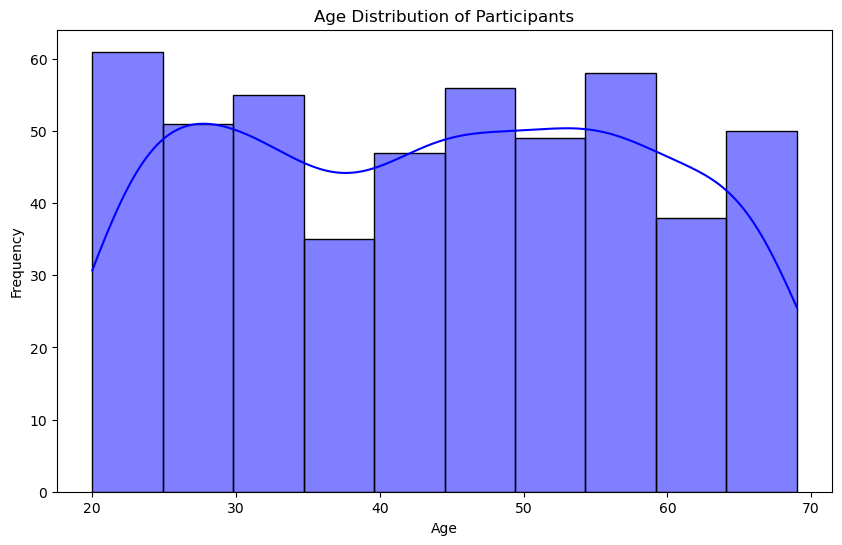

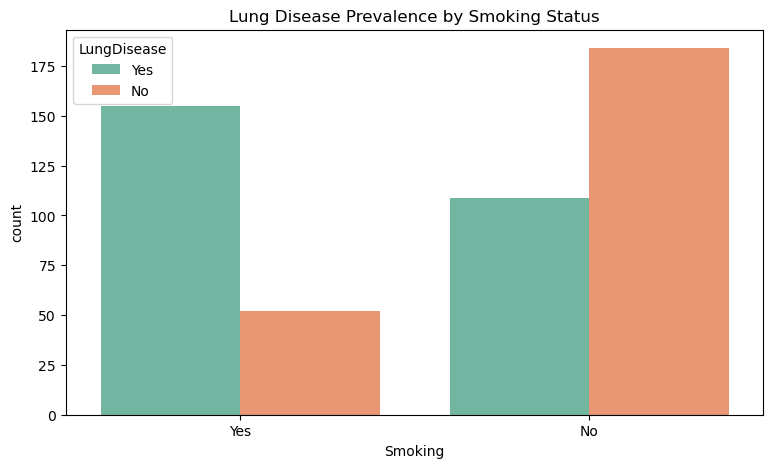

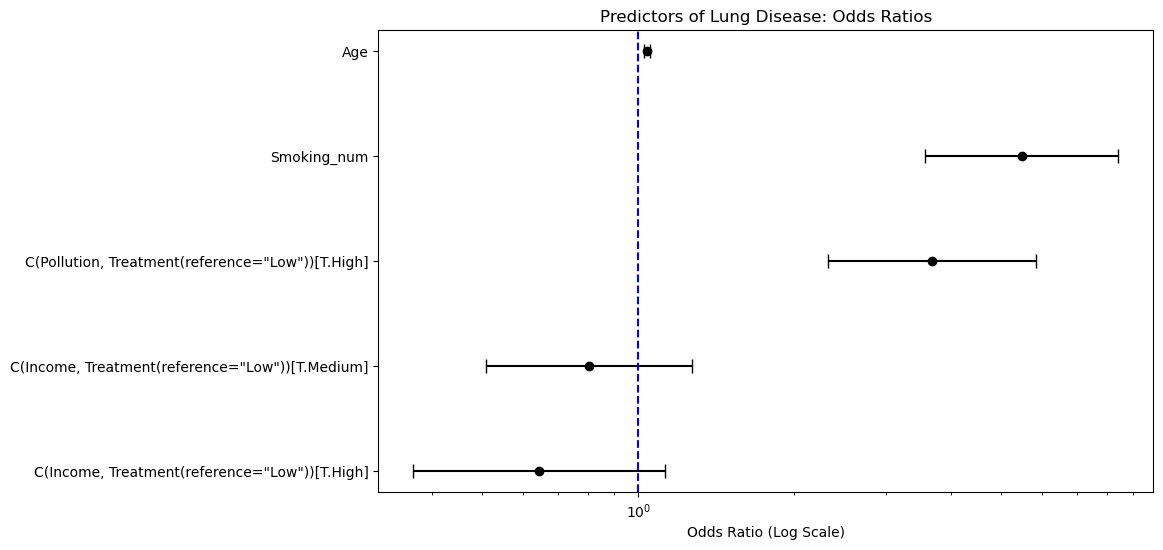

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\Assignment-on-CDA-STAT4101\lung_disease.csv")

# Summary statistics for all variables
print("--- Summary Statistics ---")
print(df.describe(include='all'))

# Age Distribution Plot
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Age Distribution of Participants')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('age_distribution.png')

# Lung Disease Prevalence by Smoking Status
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Smoking', hue='LungDisease', palette='Set2')
plt.title('Lung Disease Prevalence by Smoking Status')
plt.savefig('smoking_vs_disease.png')

# --- Logistic Regression Analysis ---

# Preprocessing: Map target and binary strings to 0 and 1
df['LungDisease_num'] = df['LungDisease'].map({'Yes': 1, 'No': 0})
df['Smoking_num'] = df['Smoking'].map({'Yes': 1, 'No': 0})

model_formula = 'LungDisease_num ~ Smoking_num + Age + C(Income, Treatment(reference="Low")) + C(Pollution, Treatment(reference="Low"))'
model = smf.logit(model_formula, data=df).fit()

# Print the full model summary
print("\n--- Logistic Regression Summary ---")
print(model.summary())

# Calculate Odds Ratios and 95% Confidence Intervals
odds_ratios = np.exp(model.params)
conf_int = np.exp(model.conf_int())
or_summary = pd.concat([odds_ratios, conf_int], axis=1)
or_summary.columns = ['Odds Ratio', '95% Lower CI', '95% Upper CI']

print("\n--- Odds Ratios and Confidence Intervals ---")
print(or_summary)

# Visualizing Odds Ratios (Forest Plot)
plt.figure(figsize=(10, 6))
# Dropping the intercept for clearer visualization of predictors
results_df = or_summary.drop('Intercept')
plt.errorbar(results_df['Odds Ratio'], range(len(results_df)),
             xerr=[results_df['Odds Ratio'] - results_df['95% Lower CI'],
                   results_df['95% Upper CI'] - results_df['Odds Ratio']],
             fmt='o', color='black', capsize=5)
plt.axvline(x=1, color='blue', linestyle='--')
plt.yticks(range(len(results_df)), results_df.index)
plt.xlabel('Odds Ratio (Log Scale)')
plt.title('Predictors of Lung Disease: Odds Ratios')
plt.xscale('log')
plt.savefig('odds_ratio_forest_plot.png')

print("\nAnalysis Complete. Plots saved as PNG files.")

ANOVA Results:
              sum_sq    df          F        PR(>F)
Program    67.416974   2.0  16.890178  6.342321e-07
Residual  173.629808  87.0        NaN           NaN

Assumptions:
- Shapiro-Wilk p-value: 0.8948
- Levene's p-value: 0.8627

Post-hoc Analysis (Tukey HSD):
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   2.1005    0.0  1.2307  2.9702   True
     A      C   0.8015 0.0772 -0.0682  1.6713  False
     B      C  -1.2989 0.0017 -2.1687 -0.4292   True
----------------------------------------------------


C:\Users\USER\AppData\Local\Temp\ipykernel_4320\892431960.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if anova_table['PR(>F)'][0] < 0.05:
C:\Users\USER\AppData\Local\Temp\ipykernel_4320\892431960.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Program', y='WeightLoss', data=data, palette='Set2')


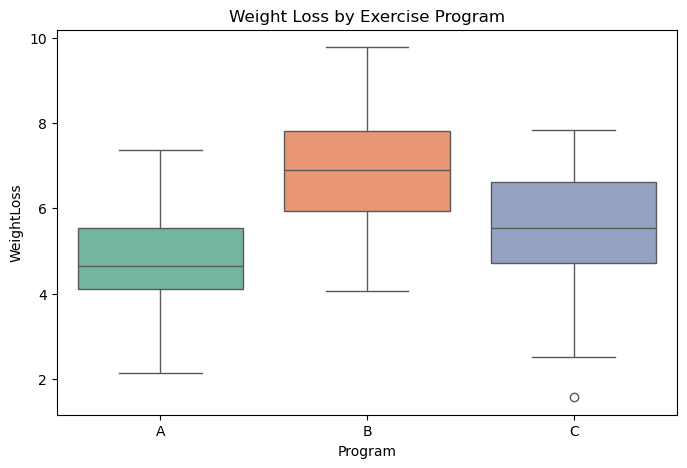

In [6]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# 1.(Simulating the 90 participants)
np.random.seed(42)
n = 30
data = pd.DataFrame({
    'Program': ['A']*n + ['B']*n + ['C']*n,
    'WeightLoss': np.concatenate([
        np.random.normal(5, 1.5, n),  
        np.random.normal(7, 1.5, n),  
        np.random.normal(5.5, 1.5, n) 
    ])
})

# 2. One-Way ANOVA
model = ols('WeightLoss ~ Program', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("ANOVA Results:")
print(anova_table)

# 3. Assumption Checking
shapiro_p = stats.shapiro(model.resid)[1]
# Homogeneity of Variance (Levene)
levene_p = stats.levene(data['WeightLoss'][data['Program'] == 'A'],
                         data['WeightLoss'][data['Program'] == 'B'],
                         data['WeightLoss'][data['Program'] == 'C'])[1]

print(f"\nAssumptions:\n- Shapiro-Wilk p-value: {shapiro_p:.4f}\n- Levene's p-value: {levene_p:.4f}")

# 4. Post-hoc Analysis (Tukey HSD)
if anova_table['PR(>F)'][0] < 0.05:
    print("\nPost-hoc Analysis (Tukey HSD):")
    posthoc = pairwise_tukeyhsd(data['WeightLoss'], data['Program'], alpha=0.05)
    print(posthoc)

# 5. Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(x='Program', y='WeightLoss', data=data, palette='Set2')
plt.title('Weight Loss by Exercise Program')
plt.show()

Problem 3:Consider the Anemia Levels in Nigeria dataset: (https://www.kaggle.com/datasets/adeolaadesina/factors-affecting-children-anemia-level/data),

Chi-Square Statistic: 203.15
P-value: 7.2798e-37
Degrees of Freedom: 12

Percentage of Anemia Category by Wealth Index:
Anemia level            Mild  Moderate  Not anemic  Severe
Wealth index combined                                     
Middle                 28.99     30.16       39.20    1.66
Poorer                 27.44     32.52       38.12    1.92
Poorest                28.39     35.66       33.89    2.06
Richer                 26.84     28.74       42.63    1.79
Richest                24.29     22.17       52.29    1.25


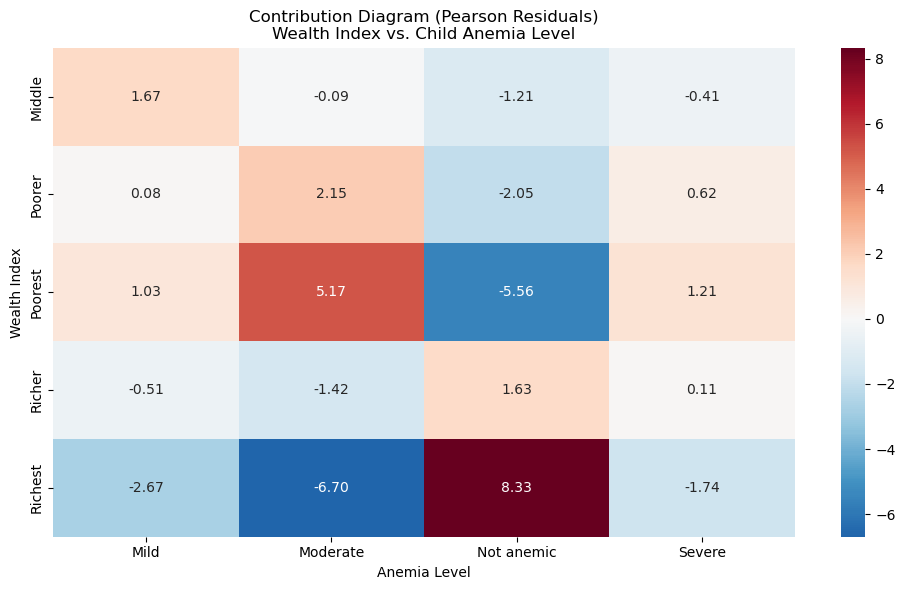

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Load and Clean Data
df = pd.read_csv(r"D:\Assignment-on-CDA-STAT4101\children anemia.csv")


clean_df = df.dropna(subset=['Wealth index combined', 'Anemia level'])

contingency_table = pd.crosstab(clean_df['Wealth index combined'], clean_df['Anemia level'])

chi2, p_val, dof, expected = chi2_contingency(contingency_table)

residuals = (contingency_table - expected) / np.sqrt(expected)

# --- Output Results ---
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_val:.4e}")
print(f"Degrees of Freedom: {dof}")

# 5. Visualization - Contribution Diagram Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(residuals, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Contribution Diagram (Pearson Residuals)\nWealth Index vs. Child Anemia Level')
plt.xlabel('Anemia Level')
plt.ylabel('Wealth Index')
plt.tight_layout()
plt.savefig('anemia_contribution_diagram.png')

# Summary of row percentages for easier interpretation
wealth_proportions = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
print("\nPercentage of Anemia Category by Wealth Index:")
print(wealth_proportions.round(2))

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# 1. Input the Contingency Table
table = np.array([
    [40, 10], # Drug A
    [10, 40], # Drug B
    [25, 25]  # Drug C
])
drugs = ['Drug A', 'Drug B', 'Drug C']


chi2_stat, p_global, dof, expected = chi2_contingency(table)


pairs = [(0, 1), (0, 2), (1, 2)]
p_values = []
for i, j in pairs:
    _, p_pair = fisher_exact(table[[i, j]])
    p_values.append(p_pair)

# Adjust p-values for multiple comparisons (Bonferroni)
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# Display Results
print(f"Global P-value: {p_global:.4e}")
for idx, (i, j) in enumerate(pairs):
    print(f"{drugs[i]} vs {drugs[j]}: Adjusted P = {p_adjusted[idx]:.4f} (Significant: {reject[idx]})")

Global P-value: 1.5230e-08
Drug A vs Drug B: Adjusted P = 0.0000 (Significant: True)
Drug A vs Drug C: Adjusted P = 0.0092 (Significant: True)
Drug B vs Drug C: Adjusted P = 0.0092 (Significant: True)


In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the dataset (binary.csv)
df = pd.read_csv(r"D:\Assignment-on-CDA-STAT4101\binary.csv")


model = smf.logit('admit ~ gre + gpa + C(rank)', data=df).fit()


print(model.summary())


odds_ratios = np.exp(model.params)
print("\n--- Odds Ratios ---")
print(odds_ratios)
     


Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.08292
Time:                        19:59:04   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.9900      1.140     -3.500      0.000      -6.224      -1.756
C(rank)[T.2]    -0.6754

PROBLEM=3

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the dataset
df = pd.read_csv(r"D:\Assignment-on-CDA-STAT4101\poisson_sim.csv")

# 2. Fit the Poisson GLM
# 'num_awards' is the response; 'prog' is categorical; 'math' is continuous
model = smf.glm('num_awards ~ C(prog) + math', data=df,
                family=sm.families.Poisson()).fit()

# 3. Model Summary
print(model.summary())

# 4. Calculate Incident Rate Ratios (IRR)
# IRR = exp(coefficient)
irr = np.exp(model.params)
print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

                 Generalized Linear Model Regression Results                  
Dep. Variable:             num_awards   No. Observations:                  200
Model:                            GLM   Df Residuals:                      196
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -182.75
Date:                Sat, 16 May 2026   Deviance:                       189.45
Time:                        19:59:47   Pearson chi2:                     212.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3881
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -5.2471      0.658     -7.969   

PROBLEM=4

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the dataset from the URL
url = "https://stats.idre.ucla.edu/stat/stata/dae/nb_data.dta"
df = pd.read_stata(url)

# 2. Fit the Negative Binomial GLM
# 'daysabs' is the response; 'prog' is categorical; 'math' is continuous
# The Negative Binomial family is used to handle overdispersion
model = smf.glm('daysabs ~ C(prog) + math', data=df,
                family=sm.families.NegativeBinomial()).fit()

# 3. Model Summary
print(model.summary())

# 4. Calculate Incident Rate Ratios (IRR) for Interpretation
# IRR = exp(coefficient)
irr = np.exp(model.params)
print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

# 5. Check for Overdispersion (Mean vs Variance)
print(f"\nMean of daysabs: {df['daysabs'].mean():.4f}")
print(f"Variance of daysabs: {df['daysabs'].var():.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                daysabs   No. Observations:                  314
Model:                            GLM   Df Residuals:                      310
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -865.68
Date:                Sat, 16 May 2026   Deviance:                       350.98
Time:                        20:00:18   Pearson chi2:                     331.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1926
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.6150      0.200     13.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [1]:
PROBLEM=5

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedPoisson

# 1. Load the dataset
df = pd.read_csv(r"D:\Assignment-on-CDA-STAT4101\fish.csv")

# 2. Define variables
y = df['count']
# Count part: Predictors for the number of fish caught
X = df[['camper', 'persons', 'child']]
X = sm.add_constant(X)

# Inflation part: Predictors for whether they didn't fish at all (Always Zero)
X_infl = df[['child', 'persons']]
X_infl = sm.add_constant(X_infl)

# 3. Fit the Zero-Inflated Poisson (ZIP) model
# inflation='logit' handles the probability of being a structural zero
model = ZeroInflatedPoisson(y, X, exog_infl=X_infl, inflation='logit').fit()

# 4. Display Results
print(model.summary())

# Calculate Interpretative Metrics
print("\n--- Odds Ratios (Probability of being a Non-Fisher) ---")
print(np.exp(model.params.filter(like='inflate')))

print("\n--- Incident Rate Ratios (Effect on Catch Count) ---")
print(np.exp(model.params.drop(model.params.filter(like='inflate').index)))

Optimization terminated successfully.
         Current function value: 3.022141
         Iterations: 23
         Function evaluations: 25
         Gradient evaluations: 25
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Sat, 16 May 2026   Pseudo R-squ.:                  0.3296
Time:                         20:02:22   Log-Likelihood:                -755.54
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                1.007e-160
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       

In [3]:
PROBLEM=7

In [2]:
%pip install pyreadstat

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:

import numpy as np
import pandas as pd  # <-- এই লাইনটি অবশ্যই থাকতে হবে
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pyreadstat

# Read the Stata file
df_stata, meta = pyreadstat.read_dta(r"D:\Assignment-on-CDA-STAT4101\ztp (1).dta")

# Save to CSV and reload
df_stata.to_csv('ztp_temp.csv', index=False)
df = pd.read_csv('ztp_temp.csv')

# Fit Negative Binomial GLM
# নোট: যদি নিচের লাইনে sm.families এ এরর দেয়, তবে sm.family (একবচন) ট্রাই করবেন
model = smf.glm('stay ~ age + hmo + died', data=df,
                family=sm.families.NegativeBinomial(alpha=1.0)).fit()

# Model Summary
print(model.summary())

# Incident Rate Ratios (IRR)
irr = np.exp(model.params)
print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   stay   No. Observations:                 1493
Model:                            GLM   Df Residuals:                     1489
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4955.3
Date:                Sat, 16 May 2026   Deviance:                       827.73
Time:                        20:14:22   Pearson chi2:                     938.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01154
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.4378      0.091     26.920      0.0

PROBLEM

In [6]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel  
from scipy.stats import nbinom                             

# Custom ZTNB Class
class ZTN(GenericLikelihoodModel):
    def loglike(self, params):
        beta = params[:-1]
        alpha = params[-1]
        if alpha <= 0: return -np.inf
        mu = np.exp(np.dot(self.exog, beta))
        size = 1 / alpha
        prob = size / (size + mu)
        l1_nb = nbinom.logpmf(self.endog, size, prob)
        p0 = (1 + alpha * mu) ** (-1/alpha)
        return np.sum(l1_nb - np.log(1 - p0))

# Load data and setup variables
df11 = pd.read_csv("ztp_temp.csv")
X11 = sm.add_constant(df11[['age', 'hmo', 'died']])

# Using GLM start params for stability
start_p = np.append(sm.GLM(df11['stay'], X11, family=sm.families.NegativeBinomial()).fit().params.values, 1.0)

# Fit Custom ZTNB Model
model11 = ZTN(df11['stay'], X11).fit(start_params=start_p)

# Summary and IRRs
print(model11.summary())
print("\n--- IRRs ---")
print(np.exp(model11.params[:-1]))
     

Optimization terminated successfully.
         Current function value: 3.185050
         Iterations: 248
         Function evaluations: 408
                                 ZTN Results                                  
Dep. Variable:                   stay   Log-Likelihood:                -4755.3
Model:                            ZTN   AIC:                             9521.
Method:            Maximum Likelihood   BIC:                             9547.
Date:                Sat, 16 May 2026                                         
Time:                        20:16:24                                         
No. Observations:                1493                                         
Df Residuals:                    1489                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")


In [7]:

import warnings
warnings.filterwarnings('ignore')